In [39]:
import pandas as pd
import geopandas as gpd
import numpy as np
import camelot
import calendar
import re
import matplotlib.pyplot as plt

In [40]:
phillyed_df = pd.read_csv('data/phillyeducation.csv') 

#### Philly education dataset

In [41]:
phillyed_df.head()

,Label (Grouping),"Philadelphia County, Pennsylvania!!Total!!Estimate","Philadelphia County, Pennsylvania!!Total!!Margin of Error","Philadelphia County, Pennsylvania!!Percent!!Estimate","Philadelphia County, Pennsylvania!!Percent!!Margin of Error","Philadelphia County, Pennsylvania!!Male!!Estimate","Philadelphia County, Pennsylvania!!Male!!Margin of Error","Philadelphia County, Pennsylvania!!Percent Male!!Estimate","Philadelphia County, Pennsylvania!!Percent Male!!Margin of Error","Philadelphia County, Pennsylvania!!Female!!Estimate",...,"Philadelphia city, Pennsylvania!!Percent!!Estimate","Philadelphia city, Pennsylvania!!Percent!!Margin of Error","Philadelphia city, Pennsylvania!!Male!!Estimate","Philadelphia city, Pennsylvania!!Male!!Margin of Error","Philadelphia city, Pennsylvania!!Percent Male!!Estimate","Philadelphia city, Pennsylvania!!Percent Male!!Margin of Error","Philadelphia city, Pennsylvania!!Female!!Estimate","Philadelphia city, Pennsylvania!!Female!!Margin of Error","Philadelphia city, Pennsylvania!!Percent Female!!Estimate","Philadelphia city, Pennsylvania!!Percent Female!!Margin of Error"
0,AGE BY EDUCATIONAL ATTAINMENT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Population 18 to 24 years,"155,837",±96,(X),(X),"75,529",±86,(X),(X),"80,308",...,(X),(X),"75,529",±86,(X),(X),"80,308",±60,(X),(X)
2,Less than high school graduate,"17,597","±1,320",11.3%,±0.8,"10,226","±1,102",13.5%,±1.5,"7,371",...,11.3%,±0.8,"10,226","±1,102",13.5%,±1.5,"7,371",±843,9.2%,±1.0
3,High school graduate (includes equival...,"50,251","±2,095",32.2%,±1.3,"26,193","±1,519",34.7%,±2.0,"24,058",...,32.2%,±1.3,"26,193","±1,519",34.7%,±2.0,"24,058","±1,464",30.0%,±1.8
4,Some college or associate's degree,"60,839","±2,076",39.0%,±1.3,"27,561","±1,437",36.5%,±1.9,"33,278",...,39.0%,±1.3,"27,561","±1,437",36.5%,±1.9,"33,278","±1,522",41.4%,±1.9


In [42]:
phillyed_df.info()
phillyed_df.shape

<class 'pandas.DataFrame'>
RangeIndex: 68 entries, 0 to 67
Data columns (total 25 columns):
 #   Column                                                              Non-Null Count  Dtype
---  ------                                                              --------------  -----
 0   Label (Grouping)                                                    68 non-null     str  
 1   Philadelphia County, Pennsylvania!!Total!!Estimate                  64 non-null     str  
 2   Philadelphia County, Pennsylvania!!Total!!Margin of Error           64 non-null     str  
 3   Philadelphia County, Pennsylvania!!Percent!!Estimate                64 non-null     str  
 4   Philadelphia County, Pennsylvania!!Percent!!Margin of Error         64 non-null     str  
 5   Philadelphia County, Pennsylvania!!Male!!Estimate                   64 non-null     str  
 6   Philadelphia County, Pennsylvania!!Male!!Margin of Error            64 non-null     str  
 7   Philadelphia County, Pennsylvania!!Percent Male!

(68, 25)

In [43]:
phillyed_df.columns

Index(['Label (Grouping)',
       'Philadelphia County, Pennsylvania!!Total!!Estimate',
       'Philadelphia County, Pennsylvania!!Total!!Margin of Error',
       'Philadelphia County, Pennsylvania!!Percent!!Estimate',
       'Philadelphia County, Pennsylvania!!Percent!!Margin of Error',
       'Philadelphia County, Pennsylvania!!Male!!Estimate',
       'Philadelphia County, Pennsylvania!!Male!!Margin of Error',
       'Philadelphia County, Pennsylvania!!Percent Male!!Estimate',
       'Philadelphia County, Pennsylvania!!Percent Male!!Margin of Error',
       'Philadelphia County, Pennsylvania!!Female!!Estimate',
       'Philadelphia County, Pennsylvania!!Female!!Margin of Error',
       'Philadelphia County, Pennsylvania!!Percent Female!!Estimate',
       'Philadelphia County, Pennsylvania!!Percent Female!!Margin of Error',
       'Philadelphia city, Pennsylvania!!Total!!Estimate',
       'Philadelphia city, Pennsylvania!!Total!!Margin of Error',
       'Philadelphia city, Pennsylvani

#### Philly income dataset

In [44]:
phillyincome = pd.read_csv('data/phillyhouseholdincome.csv') 

In [45]:
phillyincome.info()
phillyincome.shape

<class 'pandas.DataFrame'>
RangeIndex: 17 entries, 0 to 16
Data columns (total 17 columns):
 #   Column                                                                       Non-Null Count  Dtype
---  ------                                                                       --------------  -----
 0   Label (Grouping)                                                             17 non-null     str  
 1   Philadelphia County, Pennsylvania!!Households!!Estimate                      16 non-null     str  
 2   Philadelphia County, Pennsylvania!!Households!!Margin of Error               16 non-null     str  
 3   Philadelphia County, Pennsylvania!!Families!!Estimate                        16 non-null     str  
 4   Philadelphia County, Pennsylvania!!Families!!Margin of Error                 16 non-null     str  
 5   Philadelphia County, Pennsylvania!!Married-couple families!!Estimate         16 non-null     str  
 6   Philadelphia County, Pennsylvania!!Married-couple families!!Margin of E

(17, 17)

In [46]:
phillyed_df.head()

,Label (Grouping),"Philadelphia County, Pennsylvania!!Total!!Estimate","Philadelphia County, Pennsylvania!!Total!!Margin of Error","Philadelphia County, Pennsylvania!!Percent!!Estimate","Philadelphia County, Pennsylvania!!Percent!!Margin of Error","Philadelphia County, Pennsylvania!!Male!!Estimate","Philadelphia County, Pennsylvania!!Male!!Margin of Error","Philadelphia County, Pennsylvania!!Percent Male!!Estimate","Philadelphia County, Pennsylvania!!Percent Male!!Margin of Error","Philadelphia County, Pennsylvania!!Female!!Estimate",...,"Philadelphia city, Pennsylvania!!Percent!!Estimate","Philadelphia city, Pennsylvania!!Percent!!Margin of Error","Philadelphia city, Pennsylvania!!Male!!Estimate","Philadelphia city, Pennsylvania!!Male!!Margin of Error","Philadelphia city, Pennsylvania!!Percent Male!!Estimate","Philadelphia city, Pennsylvania!!Percent Male!!Margin of Error","Philadelphia city, Pennsylvania!!Female!!Estimate","Philadelphia city, Pennsylvania!!Female!!Margin of Error","Philadelphia city, Pennsylvania!!Percent Female!!Estimate","Philadelphia city, Pennsylvania!!Percent Female!!Margin of Error"
0,AGE BY EDUCATIONAL ATTAINMENT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Population 18 to 24 years,"155,837",±96,(X),(X),"75,529",±86,(X),(X),"80,308",...,(X),(X),"75,529",±86,(X),(X),"80,308",±60,(X),(X)
2,Less than high school graduate,"17,597","±1,320",11.3%,±0.8,"10,226","±1,102",13.5%,±1.5,"7,371",...,11.3%,±0.8,"10,226","±1,102",13.5%,±1.5,"7,371",±843,9.2%,±1.0
3,High school graduate (includes equival...,"50,251","±2,095",32.2%,±1.3,"26,193","±1,519",34.7%,±2.0,"24,058",...,32.2%,±1.3,"26,193","±1,519",34.7%,±2.0,"24,058","±1,464",30.0%,±1.8
4,Some college or associate's degree,"60,839","±2,076",39.0%,±1.3,"27,561","±1,437",36.5%,±1.9,"33,278",...,39.0%,±1.3,"27,561","±1,437",36.5%,±1.9,"33,278","±1,522",41.4%,±1.9


In [47]:
phillyincome.columns

Index(['Label (Grouping)',
       'Philadelphia County, Pennsylvania!!Households!!Estimate',
       'Philadelphia County, Pennsylvania!!Households!!Margin of Error',
       'Philadelphia County, Pennsylvania!!Families!!Estimate',
       'Philadelphia County, Pennsylvania!!Families!!Margin of Error',
       'Philadelphia County, Pennsylvania!!Married-couple families!!Estimate',
       'Philadelphia County, Pennsylvania!!Married-couple families!!Margin of Error',
       'Philadelphia County, Pennsylvania!!Nonfamily households!!Estimate',
       'Philadelphia County, Pennsylvania!!Nonfamily households!!Margin of Error',
       'Philadelphia city, Pennsylvania!!Households!!Estimate',
       'Philadelphia city, Pennsylvania!!Households!!Margin of Error',
       'Philadelphia city, Pennsylvania!!Families!!Estimate',
       'Philadelphia city, Pennsylvania!!Families!!Margin of Error',
       'Philadelphia city, Pennsylvania!!Married-couple families!!Estimate',
       'Philadelphia city, Penns

In [48]:
phillyincome.isnull().sum()

Label (Grouping)                                                               0
Philadelphia County, Pennsylvania!!Households!!Estimate                        1
Philadelphia County, Pennsylvania!!Households!!Margin of Error                 1
Philadelphia County, Pennsylvania!!Families!!Estimate                          1
Philadelphia County, Pennsylvania!!Families!!Margin of Error                   1
Philadelphia County, Pennsylvania!!Married-couple families!!Estimate           1
Philadelphia County, Pennsylvania!!Married-couple families!!Margin of Error    1
Philadelphia County, Pennsylvania!!Nonfamily households!!Estimate              1
Philadelphia County, Pennsylvania!!Nonfamily households!!Margin of Error       1
Philadelphia city, Pennsylvania!!Households!!Estimate                          1
Philadelphia city, Pennsylvania!!Households!!Margin of Error                   1
Philadelphia city, Pennsylvania!!Families!!Estimate                            1
Philadelphia city, Pennsylva

In [49]:
phillyincome = phillyincome.dropna()

In [50]:
phillyincome = phillyincome.rename(columns={
    'Label (Grouping)': 'category',
    'Philadelphia city, Pennsylvania!!Households!!Estimate': 'philly_households',
    'Philadelphia city, Pennsylvania!!Families!!Estimate': 'philly_families',
    'Philadelphia city, Pennsylvania!!Married-couple families!!Estimate': 'philly_married',
    'Philadelphia city, Pennsylvania!!Nonfamily households!!Estimate': 'philly_nonfamily'
})

In [51]:
phillyincome = phillyincome[['category', 'philly_households', 'philly_families', 
         'philly_married', 'philly_nonfamily']]

In [52]:
phillyincome

,category,philly_households,philly_families,philly_married,philly_nonfamily
0,Total,"679,428","349,287","185,505","330,141"
1,"Less than $10,000",8.5%,5.8%,2.0%,12.1%
2,"$10,000 to $14,999",6.0%,3.8%,1.6%,8.9%
3,"$15,000 to $24,999",8.7%,7.0%,4.2%,11.0%
4,"$25,000 to $34,999",8.4%,7.6%,4.7%,9.5%
5,"$35,000 to $49,999",10.6%,10.3%,7.0%,11.4%
6,"$50,000 to $74,999",15.7%,16.1%,14.1%,15.5%
7,"$75,000 to $99,999",11.4%,12.2%,13.0%,10.4%
8,"$100,000 to $149,999",14.6%,17.0%,21.5%,10.9%
9,"$150,000 to $199,999",7.1%,8.3%,12.3%,4.9%


#### Philly population dataset

In [53]:
phillypop = pd.read_csv('data/phillypopulation.csv')
ucity = pd.read_csv('data/university_city_citydata_extracted.csv')
phillybusiness = pd.read_csv('data/registered_local_businesses.csv')
phillyrent = pd.read_csv('data/phillyrent.csv')

In [54]:
phillypop.columns
phillypop.head()
phillypop.info()

<class 'pandas.DataFrame'>
RangeIndex: 42 entries, 0 to 41
Data columns (total 25 columns):
 #   Column                                                              Non-Null Count  Dtype
---  ------                                                              --------------  -----
 0   Label (Grouping)                                                    42 non-null     str  
 1   Philadelphia County, Pennsylvania!!Total!!Estimate                  38 non-null     str  
 2   Philadelphia County, Pennsylvania!!Total!!Margin of Error           38 non-null     str  
 3   Philadelphia County, Pennsylvania!!Percent!!Estimate                38 non-null     str  
 4   Philadelphia County, Pennsylvania!!Percent!!Margin of Error         38 non-null     str  
 5   Philadelphia County, Pennsylvania!!Male!!Estimate                   38 non-null     str  
 6   Philadelphia County, Pennsylvania!!Male!!Margin of Error            38 non-null     str  
 7   Philadelphia County, Pennsylvania!!Percent Male!

In [55]:
phillypop = phillypop.rename(columns={
    'Label (Grouping)': 'category',
    'Philadelphia city, Pennsylvania!!Total!!Estimate': 'total_pop',
    'Philadelphia city, Pennsylvania!!Percent!!Estimate': 'percent',
    'Philadelphia city, Pennsylvania!!Male!!Estimate': 'male_pop',
    'Philadelphia city, Pennsylvania!!Female!!Estimate': 'female_pop'
})

phillypop = phillypop[['category', 'total_pop', 'male_pop', 'female_pop']]
phillypop

,category,total_pop,male_pop,female_pop
0,Total population,"1,579,706","747,386","832,320"
1,AGE,NaN,NaN,NaN
2,Under 5 years,"94,457","47,919","46,538"
3,5 to 9 years,"89,137","46,327","42,810"
4,10 to 14 years,"97,827","48,930","48,897"
5,15 to 19 years,"102,041","50,650","51,391"
6,20 to 24 years,"107,174","51,803","55,371"
7,25 to 29 years,"140,837","66,975","73,862"
8,30 to 34 years,"151,601","73,415","78,186"
9,35 to 39 years,"116,437","54,106","62,331"


#### University City specific dataset

In [56]:
ucity.columns
ucity.head()
ucity.info()

<class 'pandas.DataFrame'>
RangeIndex: 103 entries, 0 to 102
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   section                103 non-null    str    
 1   metric                 103 non-null    str    
 2   university_city_value  103 non-null    float64
 3   philadelphia_value     19 non-null     float64
 4   unit                   102 non-null    str    
 5   notes                  22 non-null     str    
dtypes: float64(2), str(4)
memory usage: 9.5 KB


In [57]:
ucity = ucity[['section', 'metric', 'university_city_value', 'philadelphia_value', 'unit']]

In [58]:
ucity_filtered = ucity[ucity['metric'].str.contains(
    'income|rent|population|age|household', case=False, na=False)]

In [59]:
ucity_filtered

,section,metric,university_city_value,philadelphia_value,unit
1,basic_profile,population,20221.0,NaN,people
2,basic_profile,population_density,14972.0,11478.0,people per square mile
4,basic_profile,male_population,8511.0,NaN,people
5,basic_profile,female_population,11710.0,NaN,people
14,age_households,median_age_males,26.6,34.5,years
15,age_households,median_age_females,30.6,36.6,years
16,age_households,average_household_size,1.9,2.2,people
17,age_households,family_households_pct,18.4,36.8,percent
18,age_households,married_couple_families_among_all_households_pct,18.0,28.5,percent
19,age_households,married_couple_families_with_children_among_al...,28.5,21.1,percent


#### Philly local business dataset

In [60]:
phillybusiness.columns
phillybusiness.head()
phillybusiness.info()

<class 'pandas.DataFrame'>
RangeIndex: 421 entries, 0 to 420
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   business_name     421 non-null    str  
 1   business_address  421 non-null    str  
 2   city              421 non-null    str  
 3   state             421 non-null    str  
 4   zip_code          421 non-null    str  
 5   business_contact  421 non-null    str  
 6   email             421 non-null    str  
 7   website           30 non-null     str  
 8   approval_date     421 non-null    str  
 9   objectid          421 non-null    int64
dtypes: int64(1), str(9)
memory usage: 85.6 KB


In [26]:
phillybusiness = phillybusiness[['business_name', 'zip_code', 'approval_date']]

In [27]:
phillybusiness['zip_code'].value_counts()

zip_code
19103         30
19106         21
19102         19
19145         16
19107         15
19123         14
19147         12
19134         12
19139         11
19144         11
19125         11
19128         11
19136         11
19153         11
19119         10
19146         10
19104         10
19132         10
19111          9
19154          8
19135          8
19124          8
19143          8
19131          8
19122          8
19114          7
19127          7
19129          6
19120          6
19142          6
19115          6
19109          6
19140          6
19151          6
19116          5
19148          5
19137          5
19130          5
19110          4
19112          4
19150          4
19133          4
19141          3
19149          3
19138          3
19121          3
19002          2
19118          2
19020          1
19096          1
19462          1
19032          1
08869          1
19123 4023     1
19038          1
19073          1
60604          1
19116-3502     1
19101

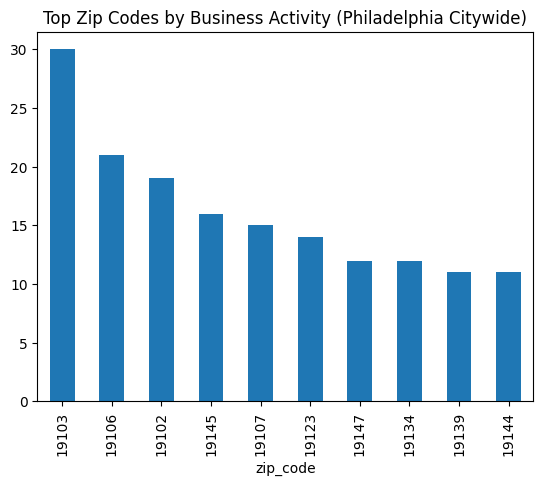

In [28]:
phillybusiness.value_counts('zip_code').head(10).plot(kind='bar')
plt.title('Top Zip Codes by Business Activity (Philadelphia Citywide)')
plt.show()

The zip code with the most local business is 19103 which includes Rittenhouse Square and is right outside of University City (19104).

In [61]:
phillybusiness[phillybusiness['zip_code'] == '19104']

,business_name,business_address,city,state,zip_code,business_contact,email,website,approval_date,objectid
0,12th Street Cantina Inc,3312 Spring Garden Street,Philadelphia,PA,19104,Christina O'Neil,accounting@12stcatering.com,NaN,2025-02-04 05:00:00+00,1
56,BROWNTOWN GROUP LLC,"4058 CHESTNUT ST, 1st Floor",PHILADELPHIA,PA,19104,JOHN THOMAS,JOHN@BROWNTOWNGROUP.COM,NaN,2025-12-10 05:00:00+00,57
62,"Campus Copy Center, lnc.",3907 WALNUT STREET,PHILADELPHIA,PA,19104,MATTHEW T . SHAPIRO,MATTHEWSHAPIRO717@GMAIL.COM,NaN,2025-08-22 04:00:00+00,63
69,CERIFIC GENERAL CONTRACTING,4433 SANSOM STREET,PHILADELPHIA,PA,19104,AHMAD HYLICK,CERIFIC.CONTRACTING@GMAIL.COM,NaN,2025-10-15 04:00:00+00,70
98,DARNELLS PROFESSIONAL PAINTING SERVICE,417 N UNION STREET,PHILADELPHIA,PA,19104,DARNELL WHITE,DARNELLWHITE0320@ICLOUD.COM,NaN,2026-01-15 05:00:00+00,100
227,"Little Warrior Media, LLC",326 S. 43RD ST,PHILADELPHIA,PA,19104,BRIAN GLAZER,BRIAN@LITTLEWARRIORAGENCY.COM,NaN,2025-08-01 04:00:00+00,228
260,"Morgan Construction Management, LLC",2929 ARCH ST SUITE 1700,PHILADELPHIA,PA,19104,ANGEL HACKNEY,AHACKNEY@MORGANCML.COM,NaN,2025-10-30 04:00:00+00,261
334,ROUNDBALL EDUCATION INC.,212 S 42ND STREET 3R,PHILADELPHIA,PA,19104,RONALD RAVENELL,ROUNDBALLEDUCATION13@GMAIL.COM,NaN,2025-10-15 04:00:00+00,335
362,SPRINGHOUSE CARPET AND UPHOLSTERY CLEANING CO.,4258 PARKSIDE AVE #3,PHILADELPHIA,PA,19104,GREGORY RUBIN,GREG@SPRINGHOUSECO.COM,www.springhouseco.com,2025-08-01 04:00:00+00,363
405,U S FACILITIES INC,30 N 41ST STREET,PHILADELPHIA,PA,19104,JAMES R. DORRIS,JIM.DORRIS@USFACILITIES.COM,WWW.USFACILITIES.COM,2025-08-01 04:00:00+00,396


In [62]:
print(f'Excluding University City, there are {421-10} local businesses in Philly')

Excluding University City, there are 411 local businesses in Philly


In [63]:
phillyrent.columns
phillyrent.head()
phillyrent.info()

<class 'pandas.DataFrame'>
RangeIndex: 27 entries, 0 to 26
Data columns (total 5 columns):
 #   Column                                              Non-Null Count  Dtype
---  ------                                              --------------  -----
 0   Label (Grouping)                                    27 non-null     str  
 1   Philadelphia County, Pennsylvania!!Estimate         27 non-null     str  
 2   Philadelphia County, Pennsylvania!!Margin of Error  27 non-null     str  
 3   Philadelphia city, Pennsylvania!!Estimate           27 non-null     str  
 4   Philadelphia city, Pennsylvania!!Margin of Error    27 non-null     str  
dtypes: str(5)
memory usage: 2.5 KB


In [64]:
phillyrent = phillyrent.rename(columns={
    'Label (Grouping)': 'category',
    'Philadelphia city, Pennsylvania!!Estimate': 'households'
})

In [65]:
phillyrent = phillyrent[['category', 'households']]

In [67]:
phillyrent

,category,households
0,Total:,"327,523"
1,With cash rent:,"315,745"
2,Less than $100,"1,096"
3,$100 to $149,343
4,$150 to $199,"1,480"
5,$200 to $249,"2,854"
6,$250 to $299,"6,488"
7,$300 to $349,"3,509"
8,$350 to $399,"3,522"
9,$400 to $449,"3,009"


In [38]:
phillyrent2['category']

1              With cash rent:
2               Less than $100
3                 $100 to $149
4                 $150 to $199
5                 $200 to $249
6                 $250 to $299
7                 $300 to $349
8                 $350 to $399
9                 $400 to $449
10                $450 to $499
11                $500 to $549
12                $550 to $599
13                $600 to $649
14                $650 to $699
15                $700 to $749
16                $750 to $799
17                $800 to $899
18                $900 to $999
19            $1,000 to $1,249
20            $1,250 to $1,499
21            $1,500 to $1,999
22            $2,000 to $2,499
23            $2,500 to $2,999
24            $3,000 to $3,499
25              $3,500 or more
26                No cash rent
Name: category, dtype: str

In [70]:
phillyrent2 = phillyrent.copy()
phillyrent2

,category,households
0,Total:,"327,523"
1,With cash rent:,"315,745"
2,Less than $100,"1,096"
3,$100 to $149,343
4,$150 to $199,"1,480"
5,$200 to $249,"2,854"
6,$250 to $299,"6,488"
7,$300 to $349,"3,509"
8,$350 to $399,"3,522"
9,$400 to $449,"3,009"


In [86]:
# make a copy
phillyrent2 = phillyrent.copy()

# remove rows you do not need
#phillyrent2 = phillyrent2[~phillyrent2['category'].isin(['Total:', 'With cash rent:'])].copy()

# create new bins that match University City
bin_map = {
    'Lessthan100': 'rent_less_than_100',
    '100to149': 'rent_100_to_199',
    '150to199': 'rent_100_to_199',
    '200to249': 'rent_200_to_299',
    '250to299': 'rent_200_to_299',
    '300to349': 'rent_300_to_399',
    '350to399': 'rent_300_to_399',
    '400to449': 'rent_400_to_499',
    '450to499': 'rent_400_to_499',
    '500to549': 'rent_500_to_599',
    '550to599': 'rent_500_to_599',
    '600to649': 'rent_600_to_699',
    '650to699': 'rent_600_to_699',
    '700to749': 'rent_700_to_799',
    '750to799': 'rent_700_to_799',
    '800to899': 'rent_800_to_899',
    '900to999': 'rent_900_to_999',
    '1,000to1,249': 'rent_1000_to_1249',
    '1,250to1,499': 'rent_1250_to_1499',
    '1,500to1,999': 'rent_1500_to_1999',
    '2,000to2,499': 'rent_2000_or_more',
    '2,500to2,999': 'rent_2000_or_more',
    '3,000to3,499': 'rent_2000_or_more',
    '3,500ormore': 'rent_2000_or_more'
}

phillyrent2['category2'] = phillyrent2['category'].str.strip().str.replace(' ','').str.replace('$','').map(bin_map)

phillyrent2[['category', 'category2', 'households']]

,category,category2,households
0,Total:,NaN,"327,523"
1,With cash rent:,NaN,"315,745"
2,Less than $100,rent_less_than_100,"1,096"
3,$100 to $149,rent_100_to_199,343
4,$150 to $199,rent_100_to_199,"1,480"
5,$200 to $249,rent_200_to_299,"2,854"
6,$250 to $299,rent_200_to_299,"6,488"
7,$300 to $349,rent_300_to_399,"3,509"
8,$350 to $399,rent_300_to_399,"3,522"
9,$400 to $449,rent_400_to_499,"3,009"


0                   NaN
1                   NaN
2                   NaN
3       rent_100_to_199
4       rent_100_to_199
5       rent_200_to_299
6       rent_200_to_299
7       rent_300_to_399
8       rent_300_to_399
9       rent_400_to_499
10      rent_400_to_499
11      rent_500_to_599
12      rent_500_to_599
13      rent_600_to_699
14      rent_600_to_699
15      rent_700_to_799
16      rent_700_to_799
17      rent_800_to_899
18      rent_900_to_999
19    rent_1000_to_1249
20    rent_1250_to_1499
21    rent_1500_to_1999
22    rent_2000_or_more
23    rent_2000_or_more
24    rent_2000_or_more
25                  NaN
26                  NaN
Name: category, dtype: str

Key Questions
- How does University City differ from the rest of Philadelphia in key socioeconomic indicators?
- Does University City have higher housing costs compared to the city overall?
- Are non-family or student-like households more common in University City?
- Is business activity more concentrated in University City than in other areas?
- Overall, does the data suggest that universities shape the economic and social structure of cities?